<a href="https://colab.research.google.com/github/baebsae3123/2-1_DeepRuningSchool/blob/main/ch7.colab_DEEPRUNING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Generative Adversarial Network (GAN)을 이용한 MNIST 이미지 생성

이 노트북은 MNIST 데이터셋을 사용하여 GAN(Generative Adversarial Network) 모델을 훈련시켜 새로운 손글씨 숫자를 생성하는 과정을 구현합니다. GAN은 생성자(Generator)와 판별자(Discriminator)라는 두 개의 신경망이 서로 경쟁하며 학습하는 구조입니다.

In [2]:
# 필요한 라이브러리들을 임포트합니다.
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Dense, Reshape, Flatten, Dropout
from tensorflow.keras.layers import BatchNormalization, Activation, LeakyReLU, UpSampling2D, Conv2D
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.optimizers import Adam

import numpy as np
import matplotlib.pyplot as plt
import os

In [ ]:
# 생성된 이미지들을 저장할 디렉토리를 만듭니다.
# './data/gan_images' 경로에 폴더가 없으면 생성하고, 이미 있다면 아무것도 하지 않습니다.
os.makedirs("./data/gan_images", exist_ok=True)

## 1. 생성자 (Generator) 모델 정의

생성자는 무작위 노이즈(latent space)를 입력받아 실제 이미지와 유사한 가짜 이미지를 생성하는 역할을 합니다. 여기서는 전치 컨볼루션(Transposed Convolution)과 업샘플링(UpSampling)을 통해 작은 크기의 특징 맵에서 시작하여 점차 이미지 크기를 키워나갑니다.

In [ ]:
# 생성자 모델을 정의합니다.
generator = Sequential()

# 1. 첫 번째 Dense 레이어: 100차원 노이즈 벡터를 받아 7*7*128 크기의 특징 맵으로 확장합니다.
#    LeakyReLU 활성화 함수를 사용하여 음수 값에 대한 기울기를 허용하여 기울기 소실 문제를 완화합니다.
generator.add(Dense(128 * 7 * 7, input_dim=100, activation=LeakyReLU(0.2)))
# 2. 배치 정규화: 각 층의 입력값을 정규화하여 학습을 안정화하고 속도를 높입니다.
generator.add(BatchNormalization())
# 3. Reshape: 1D 벡터를 7x7x128의 3D 특징 맵 형태로 변경합니다.
generator.add(Reshape((7, 7, 128)))

# 4. 업샘플링 및 컨볼루션 블록 (7x7 -> 14x14)
#    UpSampling2D: 이미지 크기를 2배로 늘립니다 (7x7 -> 14x14).
generator.add(UpSampling2D())
#    Conv2D: 5x5 커널을 사용하여 64개의 필터를 적용하고, 'same' 패딩으로 이미지 크기를 유지합니다.
generator.add(Conv2D(64, kernel_size=5, padding='same'))
#    배치 정규화
generator.add(BatchNormalization())
#    LeakyReLU 활성화 함수
generator.add(Activation(LeakyReLU(0.2)))

# 5. 두 번째 업샘플링 및 컨볼루션 블록 (14x14 -> 28x28)
#    UpSampling2D: 이미지 크기를 2배로 늘립니다 (14x14 -> 28x28).
generator.add(UpSampling2D())
#    Conv2D: 5x5 커널을 사용하여 1개의 필터를 적용합니다. MNIST는 흑백 이미지이므로 채널이 1개입니다.
#    'tanh' 활성화 함수: 픽셀 값을 -1에서 1 사이로 정규화합니다. 이는 MNIST 이미지 정규화와 일치합니다.
generator.add(Conv2D(1, kernel_size=5, padding='same', activation='tanh'))

## 2. 판별자 (Discriminator) 모델 정의

판별자는 입력된 이미지가 실제 이미지인지(True) 생성자가 만든 가짜 이미지인지(False)를 분류하는 이진 분류기 역할을 합니다. 컨볼루션 레이어와 드롭아웃을 사용하여 이미지의 특징을 추출하고 과적합을 방지합니다.

In [ ]:
# 판별자 모델을 정의합니다.
discriminator = Sequential()

# 1. 첫 번째 컨볼루션 블록: 28x28x1 이미지를 입력받습니다.
#    Conv2D: 5x5 커널, 64개 필터, strides=2로 이미지 크기를 절반으로 줄입니다 (28x28 -> 14x14).
discriminator.add(Conv2D(64, kernel_size=5, strides=2, input_shape=(28, 28, 1), padding="same"))
#    LeakyReLU 활성화 함수
discriminator.add(Activation(LeakyReLU(0.2)))
#    Dropout: 30%의 뉴런을 무작위로 비활성화하여 과적합을 방지합니다.
discriminator.add(Dropout(0.3))

# 2. 두 번째 컨볼루션 블록: 이미지 크기를 다시 절반으로 줄입니다 (14x14 -> 7x7).
#    Conv2D: 5x5 커널, 128개 필터, strides=2.
discriminator.add(Conv2D(128, kernel_size=5, strides=2, padding="same"))
#    LeakyReLU 활성화 함수
discriminator.add(Activation(LeakyReLU(0.2)))
#    Dropout: 30%의 뉴런을 무작위로 비활성화합니다.
discriminator.add(Dropout(0.3))

# 3. Flatten: 3D 특징 맵을 1D 벡터로 평탄화하여 Dense 레이어에 전달할 준비를 합니다.
discriminator.add(Flatten())
# 4. 출력 Dense 레이어: 최종적으로 이미지가 진짜일 확률을 나타내는 하나의 값을 출력합니다.
#    'sigmoid' 활성화 함수: 0과 1 사이의 확률 값을 출력합니다.
discriminator.add(Dense(1, activation='sigmoid'))

# 판별자 모델을 컴파일합니다.
#    loss: 'binary_crossentropy'를 사용하여 이진 분류 문제를 해결합니다.
#    optimizer: Adam 옵티마이저를 사용하며, 학습률(learning_rate)과 베타1(beta_1) 값을 설정합니다.
discriminator.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.0002, beta_1=0.5), metrics=['accuracy'])

# GAN 훈련 시에는 생성자가 판별자를 속이는 방향으로 학습해야 하므로,
# GAN 모델을 훈련할 때는 판별자의 가중치가 업데이트되지 않도록 trainable을 False로 설정합니다.
discriminator.trainable = False

## 3. GAN (Combined) 모델 정의

GAN 모델은 생성자와 판별자를 결합한 형태입니다. 생성자가 생성한 가짜 이미지를 판별자가 분류하도록 하며, 궁극적으로는 생성자가 판별자를 속이는 방향으로 학습하게 됩니다. 이 모델을 훈련할 때는 판별자의 가중치는 고정시키고 생성자의 가중치만 업데이트됩니다.

In [ ]:
# GAN 모델의 입력으로 100차원의 노이즈 벡터를 정의합니다.
ginput = Input(shape=(100,))

# 생성자가 노이즈 벡터를 입력받아 가짜 이미지를 생성합니다.
gen_output = generator(ginput)
# 생성자가 만든 가짜 이미지를 판별자에 입력하여 판별자의 출력을 얻습니다.
dis_output = discriminator(gen_output)

# GAN 모델을 정의합니다: 입력은 노이즈, 출력은 판별자의 판단 결과입니다.
gan = Model(ginput, dis_output)

# GAN 모델을 컴파일합니다.
#    loss: 'binary_crossentropy'를 사용합니다. 생성자는 판별자가 가짜 이미지를 진짜로 판단하게끔 학습합니다.
#    optimizer: Adam 옵티마이저를 사용하며, 판별자와 동일한 학습률과 베타1 값을 설정합니다.
gan.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.0002, beta_1=0.5))

# GAN 모델의 요약을 출력하여 구조를 확인합니다.
gan.summary()

## 4. GAN 훈련 함수 정의

`gan_train` 함수는 GAN 모델의 훈련 과정을 구현합니다. 각 에폭마다 판별자를 먼저 훈련시킨 후, 생성자를 훈련시키는 방식으로 진행됩니다. 훈련 중 주기적으로 생성된 이미지를 저장하여 학습 진행 상황을 시각적으로 확인할 수 있습니다.

In [ ]:
# GAN 훈련 함수를 정의합니다.
def gan_train(epoch, batch_size, saving_interval):
    # MNIST 데이터셋을 불러옵니다. 여기서는 훈련 이미지(X_train)만 필요합니다.
    (X_train, _), (_, _) = mnist.load_data()

    # 이미지 데이터를 28x28 흑백 이미지(채널 1) 형태로 변환하고, 데이터 타입을 float32로 설정합니다.
    X_train = X_train.reshape(X_train.shape[0], 28, 28, 1).astype('float32')

    # 픽셀 값을 -1에서 1 사이로 정규화합니다. 이는 생성자의 'tanh' 활성화 함수와 일치합니다.
    # (원본 0~255) -> (0~255 - 127.5) / 127.5 = (-127.5~127.5) / 127.5 = (-1~1)
    X_train = (X_train - 127.5) / 127.5

    # 판별자 훈련을 위한 레이블을 준비합니다.
    # 실제 이미지에 대한 레이블은 '1' (진짜),
    # 가짜 이미지에 대한 레이블은 '0' (가짜)입니다.
    true = np.ones((batch_size, 1))
    fake = np.zeros((batch_size, 1))

    # 지정된 에폭(훈련 반복 횟수)만큼 GAN을 훈련합니다.
    for i in range(epoch):
        # === 1. 판별자(Discriminator) 훈련 ===
        # 판별자는 훈련 시 가중치가 업데이트되어야 하므로 trainable을 True로 설정합니다.
        discriminator.trainable = True

        # 실제 이미지 배치 선택: X_train에서 batch_size만큼 무작위로 이미지를 선택합니다.
        idx = np.random.randint(0, X_train.shape[0], batch_size)
        imgs = X_train[idx]
        # 실제 이미지를 판별자에 입력하고, 레이블 '1'과 함께 훈련시킵니다.
        d_loss_real = discriminator.train_on_batch(imgs, true)

        # 가짜 이미지 배치 생성: 100차원의 무작위 노이즈 벡터를 생성합니다.
        noise = np.random.normal(0, 1, (batch_size, 100))
        # 생성자에 노이즈를 입력하여 가짜 이미지를 생성합니다. (verbose=0으로 로그 출력 안 함)
        gen_imgs = generator.predict(noise, verbose=0)
        # 가짜 이미지를 판별자에 입력하고, 레이블 '0'과 함께 훈련시킵니다.
        d_loss_fake = discriminator.train_on_batch(gen_imgs, fake)

        # 실제 이미지와 가짜 이미지에 대한 판별자 손실의 평균을 계산합니다.
        d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

        # === 2. 생성자(Generator) 훈련 ===
        # 생성자 훈련 시에는 판별자의 가중치는 업데이트되지 않도록 trainable을 False로 설정합니다.
        # 이렇게 해야 생성자가 판별자를 속이는 방향으로만 학습하게 됩니다.
        discriminator.trainable = False

        # 새로운 무작위 노이즈 벡터를 생성합니다.
        noise = np.random.normal(0, 1, (batch_size, 100))
        # GAN 모델(생성자+판별자)을 훈련합니다. 생성자는 판별자가 가짜 이미지를 '진짜'라고 판단하게끔(레이블 '1') 노력합니다.
        g_loss = gan.train_on_batch(noise, true)

        # 100 에폭마다 현재 손실 값을 출력하여 훈련 진행 상황을 모니터링합니다.
        if i % 100 == 0:
            print('epoch:%d' % i, 'd_loss:%.4f' % d_loss[0], 'g_loss:%.4f' % g_loss)

        # === 3. 생성된 이미지 저장 (시각화) ===
        # 지정된 saving_interval마다 생성된 이미지들을 저장합니다.
        if i % saving_interval == 0:
            # 25개의 가짜 이미지를 생성하기 위한 노이즈 벡터를 만듭니다.
            noise = np.random.normal(0, 1, (25, 100))
            gen_imgs = generator.predict(noise, verbose=0)

            # 생성된 이미지의 픽셀 값을 0에서 1 사이로 다시 스케일링합니다.
            # (현재 -1~1 범위) -> (0~1 범위)
            gen_imgs = 0.5 * gen_imgs + 0.5

            # 5x5 그리드 형태로 이미지를 표시하고 저장하기 위한 Matplotlib 설정을 합니다.
            fig, axs = plt.subplots(5, 5)
            count = 0
            for j in range(5):
                for k in range(5):
                    # 각 서브플롯에 생성된 이미지를 표시합니다. 흑백 이미지이므로 cmap='gray'를 사용합니다.
                    axs[j, k].imshow(gen_imgs[count, :, :, 0], cmap='gray')
                    # 축을 표시하지 않습니다.
                    axs[j, k].axis('off')
                    count += 1
            # 생성된 이미지를 파일로 저장합니다. 파일명에는 현재 에폭 번호가 포함됩니다.
            fig.savefig("./data/gan_images/gan_mnist_%d.png" % i)
            plt.close(fig) # 불필요한 메모리 사용 방지를 위해 그림을 닫습니다.

## 5. GAN 훈련 실행

이제 정의된 `gan_train` 함수를 호출하여 GAN 모델을 훈련시킵니다. 여기서는 총 4001 에폭 동안 훈련하며, 배치 크기는 32로 설정하고, 800 에폭마다 중간 생성 이미지를 저장하도록 합니다.

In [ ]:
# GAN 훈련을 시작합니다.
# epoch: 총 4001번의 훈련 반복 (0부터 4000까지)
# batch_size: 한 번에 처리할 이미지 수 (32개)
# saving_interval: 생성된 이미지를 저장할 에폭 간격 (800 에폭마다 저장)
gan_train(4001, 32, 800)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 28, 28, 1)      │       865,281 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 1)              │       212,865 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,078,146 (4.11 MB)

 Trainable params: 852,609 (3.25 MB)

 Non-trainable params: 225,537 (881.00 KB)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
epoch:0 d_loss:0.6772 g_loss:0.5970
epoch:100 d_loss:0.4355 g_loss:0.3981
epoch:200 d_loss:0.4420 g_loss:0.5013
epoch:300 d_loss:0.5370 g_loss:0.6135
epoch:400 d_loss:0.5907 g_loss:0.6646
epoch:500 d_loss:0.6155 g_loss:0.6958
epoch:600 d_loss:0.6265 g_loss:0.7177
epoch:700 d_loss:0.6326 g_loss:0.7343
epoch:800 d_loss:0.6353 g_loss:0.7477
epoch:900 d_loss:0.6386 g_loss:0.7562
epoch:1000 d_loss:0.6442 g_loss:0.7557
epoch:1100 d_loss:0.6486 g_loss:0.7566
epoch:1200 d_loss:0.6510 g_loss:0.7600
epoch:1300 d_loss:0.6530 g_loss:0.7639
epoch:1400 d_loss:0.6544 g_loss:0.7668
epoch:1500 d_loss:0.6555 g_loss:0.7704
epoch:1600 d_loss:0.6569 g_loss:0.7724
epoch:1700 d_loss:0.6581 g_loss:0.7740
epoch:1800 d_loss:0.6592 g_loss:0.7753
epoch:1900 d_loss:0.6602 g_loss:0.7759
epoch:2000 d_loss:0.6610 g_loss:0.7772
epoch:2100 d_loss:0.6618 g_loss:0.7776
epoch:2200 d_loss:0.6625 g_loss:0.7780
epoch:2300 d_loss:0.6632 g_loss:0.7781
epoch:2400 d_loss:0.6638 

KeyboardInterrupt: 

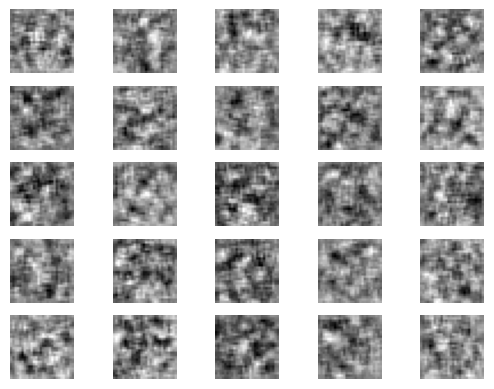

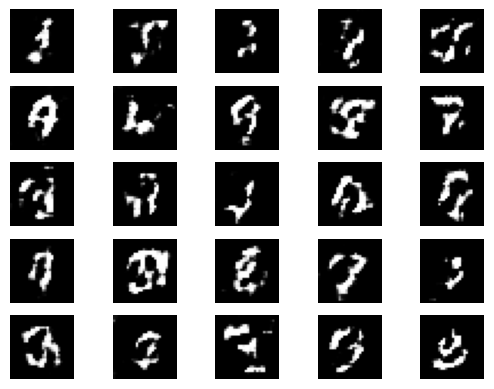

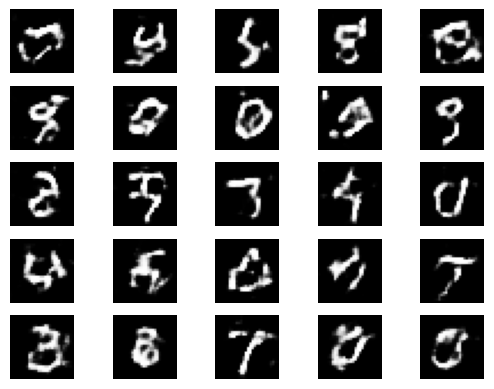

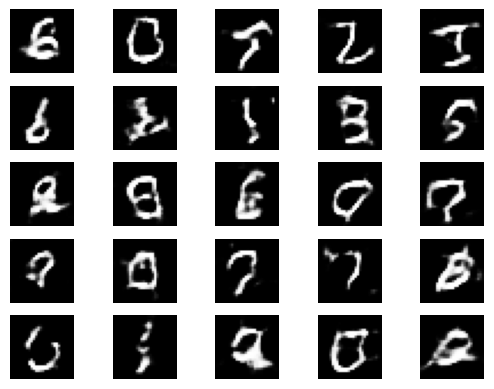

In [1]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Dense, Reshape, Flatten, Dropout
from tensorflow.keras.layers import BatchNormalization, Activation, LeakyReLU, UpSampling2D, Conv2D
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.optimizers import Adam

import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("./data/gan_images", exist_ok=True)

# 생성자 모델을 만듭니다.
generator = Sequential()
generator.add(Dense(128*7*7, input_dim=100, activation=LeakyReLU(0.2)))
generator.add(BatchNormalization())
generator.add(Reshape((7, 7, 128)))
generator.add(UpSampling2D())
generator.add(Conv2D(64, kernel_size=5, padding='same'))
generator.add(BatchNormalization())
generator.add(Activation(LeakyReLU(0.2)))
generator.add(UpSampling2D())
generator.add(Conv2D(1, kernel_size=5, padding='same', activation='tanh'))

# 판별자 모델을 만듭니다.
discriminator = Sequential()
discriminator.add(Conv2D(64, kernel_size=5, strides=2, input_shape=(28,28,1), padding="same"))
discriminator.add(Activation(LeakyReLU(0.2)))
discriminator.add(Dropout(0.3))
discriminator.add(Conv2D(128, kernel_size=5, strides=2, padding="same"))
discriminator.add(Activation(LeakyReLU(0.2)))
discriminator.add(Dropout(0.3))
discriminator.add(Flatten())
discriminator.add(Dense(1, activation='sigmoid'))
discriminator.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.0002, beta_1=0.5), metrics=['accuracy'])
discriminator.trainable = False

# 생성자와 판별자 모델을 연결시키는 gan 모델을 만듭니다.
ginput = Input(shape=(100,))
dis_output = discriminator(generator(ginput))
gan = Model(ginput, dis_output)
gan.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.0002, beta_1=0.5))
gan.summary()

# 신경망을 실행시키는 함수를 만듭니다.
def gan_train(epoch, batch_size, saving_interval):
    # MNIST 데이터를 불러옵니다.
    # 앞서 불러온 적 있는 MNIST를 다시 이용합니다. 단, 테스트 과정은 필요 없고
    # 이미지만 사용할 것이기 때문에 X_train만 불러왔습니다.
    (X_train, _), (_, _) = mnist.load_data()
    X_train = X_train.reshape(X_train.shape[0], 28, 28, 1).astype('float32')
    X_train = (X_train - 127.5) / 127.5 # 픽셀 값은 0에서 255 사이의 값입니다.
    # 이전에는 255로 나누어 줄 때는 이를 0~1 사이의 값으로 바꾸었던 것인데,
    # 여기서는 127.5를 빼준 뒤 127.5로 나누어 줌으로 인해 -1에서 1 사이의
    # 값으로 바뀌게 됩니다.

    true = np.ones((batch_size, 1))
    fake = np.zeros((batch_size, 1))

    for i in range(epoch):
        discriminator.trainable = True

        # 실제 데이터를 판별자에 입력하는 부분입니다.
        idx = np.random.randint(0, X_train.shape[0], batch_size)
        imgs = X_train[idx]
        d_loss_real = discriminator.train_on_batch(imgs, true)

        # 가상 이미지를 판별자에 입력하는 부분입니다.
        noise = np.random.normal(0, 1, (batch_size, 100))
        gen_imgs = generator.predict(noise, verbose=0)
        d_loss_fake = discriminator.train_on_batch(gen_imgs, fake)

        # 판별자와 생성자의 오차를 계산합니다.
        d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)
        discriminator.trainable = False

        noise = np.random.normal(0, 1, (batch_size, 100))
        g_loss = gan.train_on_batch(noise, true)

        if i % 100 == 0:
            print('epoch:%d' % i, 'd_loss:%.4f' % d_loss[0], 'g_loss:%.4f' % g_loss)

        # 이 부분은 중간 과정을 이미지로 저장해 주는 부분입니다.
        # 이 장의 주요 내용과 관련이 없어 소스 코드만 첨부합니다.
        # 만들어진 이미지들은 gan_images 폴더에 저장됩니다.
        if i % saving_interval == 0:
            # r, c = 5, 5
            noise = np.random.normal(0, 1, (25, 100))
            gen_imgs = generator.predict(noise, verbose=0)

            # Rescale images 0 - 1
            gen_imgs = 0.5 * gen_imgs + 0.5

            fig, axs = plt.subplots(5, 5)
            count = 0
            for j in range(5):
                for k in range(5):
                    axs[j, k].imshow(gen_imgs[count, :, :, 0], cmap='gray')
                    axs[j, k].axis('off')
                    count += 1
            fig.savefig("./data/gan_images/gan_mnist_%d.png" % i)

# 4000번 반복되고, 배치 사이즈는 32, 800번마다 결과가 저장되게 하였습니다.
gan_train(4001, 32, 800)

In [3]:
# 생성자 모델 만들기
autoencoder = Sequential()

# 인코딩 부분
autoencoder.add(Conv2D(16, kernel_size=3, padding='same', input_shape=(28, 28, 1), activation='relu'))  # ..... ①
autoencoder.add(MaxPooling2D(pool_size=2, padding='same'))  # ..... ②
autoencoder.add(Conv2D(8, kernel_size=3, activation='relu', padding='same'))  # ..... ③
autoencoder.add(MaxPooling2D(pool_size=2, padding='same'))  # ..... ④
autoencoder.add(Conv2D(8, kernel_size=3, strides=2, padding='same', activation='relu'))  # ..... ⑤

# 디코딩 부분
autoencoder.add(Conv2D(8, kernel_size=3, padding='same', activation='relu'))  # ..... ⑥
autoencoder.add(UpSampling2D())  # ..... ⑦
autoencoder.add(Conv2D(8, kernel_size=3, padding='same', activation='relu'))  # ..... ⑧
autoencoder.add(UpSampling2D())  # ..... ⑨
autoencoder.add(Conv2D(16, kernel_size=3, activation='relu'))  # ..... ⑩
autoencoder.add(UpSampling2D())  # ..... ⑪
autoencoder.add(Conv2D(1, kernel_size=3, padding='same', activation='sigmoid'))  # ..... ⑫

# 전체 구조 확인
autoencoder.summary()  # ..... ⑬

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


NameError: name 'MaxPooling2D' is not defined